# Phishing Email Detection – Classical Machine Learning Models (TF-IDF + LR + SVM + RF)

This notebook trains and evaluates classical machine learning models using:

- TF-IDF feature extraction
- Logistic Regression (baseline)
- Linear SVM (strong linear classifier)
- Random Forest (non-linear ensemble classifierbased on decision trees)

We evaluate using:
- Accuracy
- Precision / Recall / F1
- Confusion Matrix

Models and vectorizer are saved to `../outputs/models/`.

In [1]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib
import matplotlib.pyplot as plt

## 1) Load Clean Dataset

In [2]:
DATA_PATH = Path("../data/processed/clean_emails.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()

Dataset shape: (29833, 4)
label
1    15447
0    14386
Name: count, dtype: int64


,text,label,source,clean_text
0,"hpl nom for may 25 , 2001 ( see attached file ...",0,enron,hpl nom for may see attached file hplno xls hp...
1,re : nom / actual vols for 24 th - - - - - - -...,0,enron,re nom actual vols for th forwarded by sabrae ...
2,"enron actuals for march 30 - april 1 , 201 est...",0,enron,enron actuals for march april estimated actual...
3,"hpl nom for june 1 , 2001 ( see attached file ...",0,enron,hpl nom for june see attached file hplno xls h...
4,# 9760 tried to get fancy with your address an...,0,enron,tried to get fancy with your address and it ca...


## 2) Train/Test Split (80/20, Stratified)

Stratified split keeps label proportions similar in train and test.

In [3]:
X = df["clean_text"].fillna(" ")
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("\nTrain label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())

Train size: 23866
Test size: 5967

Train label counts:
 label
1    12357
0    11509
Name: count, dtype: int64

Test label counts:
 label
1    3090
0    2877
Name: count, dtype: int64


## 3) TF-IDF Feature Extraction

Convert text to numerical vectors suitable for ML models.

In [4]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)   # unigrams + bigrams (helps phishing phrases)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vector shape:", X_train_vec.shape)

Vector shape: (23866, 5000)


## 4) Logistic Regression (Baseline)

In [5]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (LR):\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.983911513323278

Classification Report (LR):

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2877
           1       0.98      0.99      0.98      3090

    accuracy                           0.98      5967
   macro avg       0.98      0.98      0.98      5967
weighted avg       0.98      0.98      0.98      5967



## 5) Linear SVM

In [6]:
svm = LinearSVC()
svm.fit(X_train_vec, y_train)

y_pred_svm = svm.predict(X_test_vec)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report (SVM):\n")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.9849170437405732

Classification Report (SVM):

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2877
           1       0.98      0.99      0.99      3090

    accuracy                           0.98      5967
   macro avg       0.98      0.98      0.98      5967
weighted avg       0.98      0.98      0.98      5967



## 6) Random Forest Classifier

Random Forest is a **non-linear ensemble model** made of many decision trees.

Each tree learns from a random subset of:
- training samples (bootstrap sampling)
- features (feature randomness)

The final prediction is decided by **majority voting** across all trees.

Random Forest helps compare:
- linear models (Logistic Regression, SVM)
vs
- non-linear model (Random Forest)

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # useful if imbalance exists
)

rf.fit(X_train_vec, y_train)
y_pred_rf = rf.predict(X_test_vec)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (RF):\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9813976872800402

Classification Report (RF):

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2877
           1       0.98      0.99      0.98      3090

    accuracy                           0.98      5967
   macro avg       0.98      0.98      0.98      5967
weighted avg       0.98      0.98      0.98      5967



## 7) Confusion Matrices (LR + SVM + RF)

Confusion matrices show the count of:
- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

This helps understand model behaviour beyond accuracy.

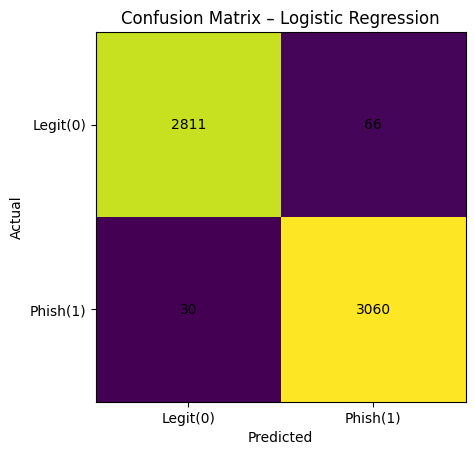

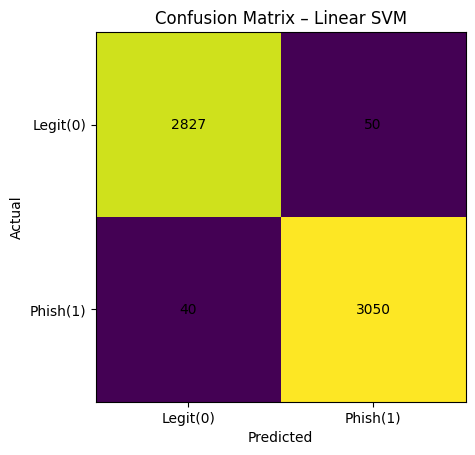

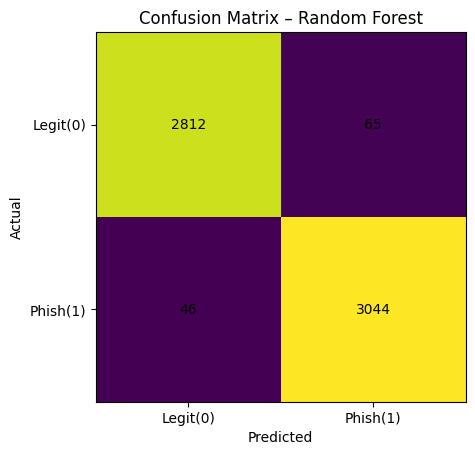

In [8]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Legit(0)", "Phish(1)"])
    plt.yticks([0, 1], ["Legit(0)", "Phish(1)"])
    for (i, j), val in zip([(0,0),(0,1),(1,0),(1,1)], cm.flatten()):
        plt.text(j, i, str(val), ha='center', va='center')
    plt.show()

plot_conf_matrix(y_test, y_pred_lr, "Confusion Matrix – Logistic Regression")
plot_conf_matrix(y_test, y_pred_svm, "Confusion Matrix – Linear SVM")
plot_conf_matrix(y_test, y_pred_rf, "Confusion Matrix – Random Forest")

## 7) Save Models and Vectorizer

Saved to: `../outputs/models/`

In [9]:
MODELS_DIR = Path("../outputs/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(vectorizer, MODELS_DIR / "tfidf_vectorizer.pkl")
joblib.dump(lr, MODELS_DIR / "logistic_regression.pkl")
joblib.dump(svm, MODELS_DIR / "linear_svm.pkl")
joblib.dump(rf, MODELS_DIR / "random_forest.pkl")

print("✅ Saved models to:", MODELS_DIR)

✅ Saved models to: ..\outputs\models


## 8) Model Performance Comparison

To compare the effectiveness of different models, the evaluation results are summarised in a table.

The following models are compared:

- Logistic Regression (baseline)
- Support Vector Machine
- Random Forest

The comparison focuses on the phishing class (label *1*), which is the most critical for security systems.

In [10]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision (Phish)": precision_score(y_test, y_pred_lr),
    "Recall (Phish)": recall_score(y_test, y_pred_lr),
    "F1 Score (Phish)": f1_score(y_test, y_pred_lr)
})

# SVM
results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision (Phish)": precision_score(y_test, y_pred_svm),
    "Recall (Phish)": recall_score(y_test, y_pred_svm),
    "F1 Score (Phish)": f1_score(y_test, y_pred_svm)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision (Phish)": precision_score(y_test, y_pred_rf),
    "Recall (Phish)": recall_score(y_test, y_pred_rf),
    "F1 Score (Phish)": f1_score(y_test, y_pred_rf)
})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (Phish),Recall (Phish),F1 Score (Phish)
0,Logistic Regression,0.983912,0.978887,0.990291,0.984556
1,Linear SVM,0.984917,0.983871,0.987055,0.985460
2,Random Forest,0.981398,0.979093,0.985113,0.982094
